In [1]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split


# Loading Processed Dataset
bundle = joblib.load("../backend/models/drug/drug_data_bundle.pkl")
categorical_cols = joblib.load("../backend/models/drug/categorical_cols.pkl")
encoders_dict = joblib.load("../backend/models/drug/encoders_dict.pkl")

X_train = bundle["X_train"]
X_test = bundle["X_test"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]

print("Success!")
print(f"X_train size: {X_train.shape}, X_test size: {X_test.shape}")

Success!
X_train size: (160, 4), X_test size: (40, 4)


In [2]:
# Decision Tree Model
dt_model = DecisionTreeClassifier(
                min_samples_split=3,
                min_samples_leaf=8,
                max_depth=4,
                criterion='entropy',
                random_state=42,
)

In [3]:
# K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring="accuracy")

print("K-Fold (K=5) Validation Scores:", cv_scores)
print("Average CV Validation: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std() * 2))

K-Fold (K=5) Validation Scores: [1. 1. 1. 1. 1.]
Average CV Validation: 1.0000 (+/- 0.0000)


In [4]:
# Training the Model
dt_model.fit(X_train, y_train)
print("\nModel is trained!")


Model is trained!


In [5]:
# Train Set Performance (For Overfitting)
y_train_pred = dt_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("=" * 40)
print("          TRAIN SET PERFORMANCE          ")
print("=" * 40)
print(f"Train Accuracy: {train_accuracy:.4f}\n")
print("Train Classification (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred))

# Test Set Performance
y_test_pred = dt_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 40)
print("          TEST SET PERFORMANCE           ")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy:.4f}\n")
print("Test Classification (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred))

          TRAIN SET PERFORMANCE          
Train Accuracy: 1.0000

Train Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00        18
       drugB       1.00      1.00      1.00        13
       drugC       1.00      1.00      1.00        13
       drugX       1.00      1.00      1.00        43
       drugY       1.00      1.00      1.00        73

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160

          TEST SET PERFORMANCE           
Test Accuracy: 0.9750

Test Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       drugA       0.83      1.00      0.91         5
       drugB       1.00      0.67      0.80         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      1.00      1.00        11
      

In [6]:
# Saving the Model
joblib.dump(dt_model, "../backend/models/drug/decision_tree_model.pkl")
print("Trained model is successfully saved!")

Trained model is successfully saved!


--- Feature Importance Scores ---
       Feature  Importance
0      Na_to_K    0.505045
1           BP    0.315887
2          Age    0.096542
3  Cholesterol    0.082526


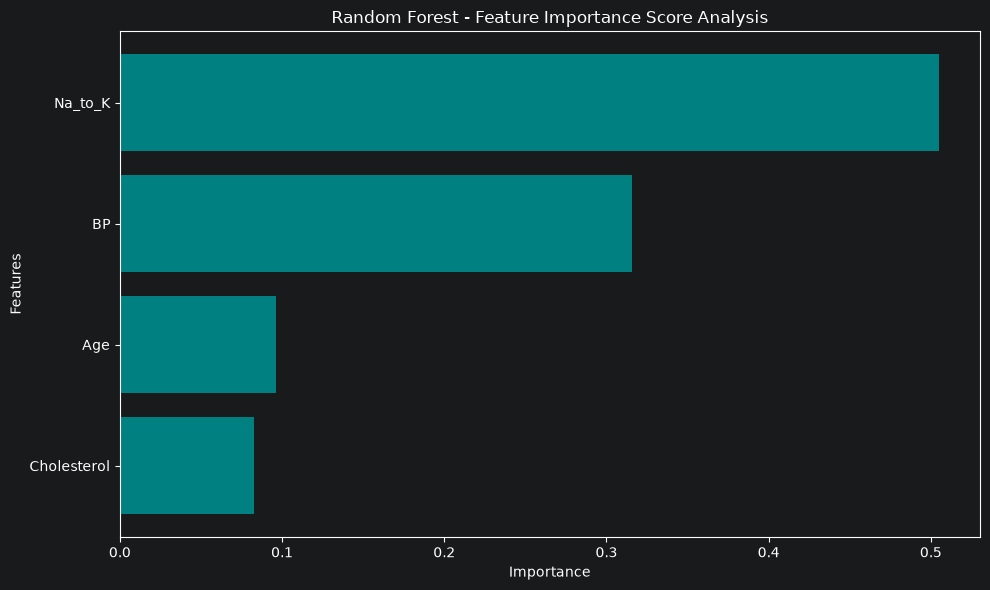

In [7]:

# 1. Feature importance
importances = dt_model.feature_importances_
feature_names = (
    X_train.columns
)

# 2. Converting to DataFrame
feature_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
)
feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=False)

print("--- Feature Importance Scores ---")
print(feature_imp_df)

# 3. Virtualization
plt.figure(figsize=(10, 6))
plt.barh(
    feature_imp_df["Feature"], feature_imp_df["Importance"], color="teal"
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest - Feature Importance Score Analysis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
# 1. Read the original raw CSV file directly
df = pd.read_csv("../datasets/drug200.csv")

# 2. Split into X and y
X = df.drop(columns=["Drug", "Sex"])
y = df["Drug"]

# 3. Split into Train-Test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. KATEGORİK STRING SÜTUNLARI ENCODE ETME ADIMI ---
# Daha önce diske kaydettiğimiz encoder'ları yüklüyoruz
encoders = joblib.load("../backend/models/drug/encoders_dict.pkl")
categorical_cols = joblib.load("../backend/models/drug/categorical_cols.pkl")

# Train ve Test verilerindeki string sütunları, eğitimde öğrenilen kurallarla sayıya çevir
for col in categorical_cols:
  if col in X_train_raw.columns:
    encoder = encoders[col]
    # DİKKAT: Test ve ham verilere asla fit_transform YAPILMAZ, sadece transform uygulanır!
    X_train_raw[[col]] = encoder.transform(X_train_raw[[col]])
    X_test_raw[[col]] = encoder.transform(X_test_raw[[col]])

print("Raw data loaded, strings encoded, and split!")

# 5. Train the model with encoded raw data
dt_raw_model = DecisionTreeClassifier(
    min_samples_split=3,
    min_samples_leaf=8,
    max_depth=4,
    criterion="entropy",
    random_state=42,
)
dt_raw_model.fit(X_train_raw, y_train)

# 6. Train Set Performance For Raw Model
y_train_pred_raw = dt_raw_model.predict(X_train_raw)
train_accuracy_raw = accuracy_score(y_train, y_train_pred_raw)

print("=" * 40)
print("          RAW DATA - TRAIN SET PERFORMANCE          ")
print("=" * 40)
print(f"Train Accuracy: {train_accuracy_raw:.4f}\n")
print("Train Classification Report (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred_raw))

# 7. Test Set Performance For Raw Model (Real success)
y_test_pred_raw = dt_raw_model.predict(X_test_raw)
test_accuracy_raw = accuracy_score(y_test, y_test_pred_raw)

print("=" * 40)
print("          RAW DATA - TEST SET PERFORMANCE           ")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy_raw:.4f}\n")
print("Test Classification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred_raw))

Raw data loaded, strings encoded, and split!
          RAW DATA - TRAIN SET PERFORMANCE          
Train Accuracy: 1.0000

Train Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00        18
       drugB       1.00      1.00      1.00        13
       drugC       1.00      1.00      1.00        13
       drugX       1.00      1.00      1.00        43
       drugY       1.00      1.00      1.00        73

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160

          RAW DATA - TEST SET PERFORMANCE           
Test Accuracy: 0.9750

Test Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       drugA       0.83      1.00      0.91         5
       drugB       1.00      0.67      0.80         3
       drugC       1.00      1.00